# Auto-catégorisation des transactions — Entraînement & comparaison de modèles

**Objectif** : entraîner un modèle qui prédit la catégorie d'une transaction (`Food`, `Transport`, `Bills`, ...) à partir de sa description textuelle.

**Données** : `categorizer_dataset_processed.csv` — 106 exemples uniques, 9 catégories (fusion des jeux Kaggle nettoyés + exemples statiques du projet).

**Note méthodologique** : avec seulement 8 à 21 exemples par catégorie, un split train/test fixe serait trop instable pour être fiable (trop peu de points de test par classe). On utilise donc une **validation croisée stratifiée (StratifiedKFold)** pour évaluer les modèles, puis on entraîne le modèle final sur l'intégralité des données avant de le sauvegarder pour la production.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import pickle, os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Chargement des données

In [2]:
df = pd.read_csv("../data/proceed/categorizer_dataset_processed.csv")
print(df.shape)
df.sample(10, random_state=1)

(106, 3)


,text,category,source
66,personal loan installment,EMI,kaggle
35,crypto investment,Investment,kaggle
59,food court payment,Food,kaggle
77,bakery,Food,static
39,mobile recharge,Bills,kaggle
56,online shopping payment,Shopping,kaggle
55,college fees payment,Education,kaggle
87,rent payment,Bills,static
31,home loan emi,EMI,kaggle
58,clothing store bill,Shopping,kaggle


## 2. Exploration — distribution des catégories

category
Food             21
Transport        18
Shopping         15
EMI              10
Entertainment     9
Bills             9
Investment        8
Health            8
Education         8
Name: count, dtype: int64


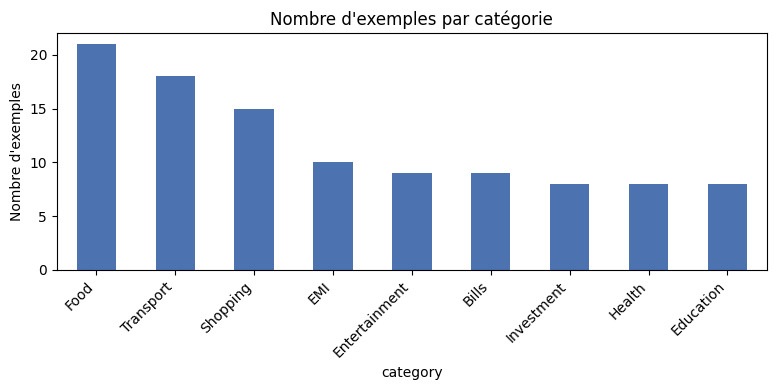

In [3]:
counts = df["category"].value_counts()
print(counts)

plt.figure(figsize=(8, 4))
counts.plot(kind="bar", color="#4C72B0")
plt.title("Nombre d'exemples par catégorie")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Comparaison de modèles par validation croisée

On compare deux approches suggérées par la roadmap du projet :
- **TF-IDF + Multinomial Naive Bayes**
- **TF-IDF + Logistic Regression**

`StratifiedKFold` garde une proportion équilibrée de chaque catégorie dans chaque pli, ce qui est essentiel vu la petite taille du dataset.

In [4]:
X = df["text"]
y = df["category"]

# 5 plis : la classe la plus petite a 8 exemples, donc max 5 plis pour garder >=1 exemple/classe/pli
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Naive Bayes (TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", MultinomialNB()),
    ]),
    "Logistic Regression (TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
    ]),
}

results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:32s} accuracy = {scores.mean():.3f} ± {scores.std():.3f}   (plis: {np.round(scores, 2)})")

Naive Bayes (TF-IDF)             accuracy = 0.510 ± 0.059   (plis: [0.45 0.48 0.62 0.52 0.48])
Logistic Regression (TF-IDF)     accuracy = 0.567 ± 0.074   (plis: [0.45 0.57 0.67 0.62 0.52])


C:\Users\msi\AppData\Local\Temp\ipykernel_15632\1594039472.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys())


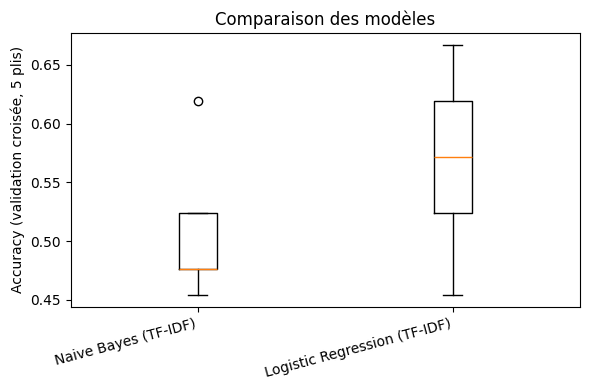

In [5]:
plt.figure(figsize=(6, 4))
plt.boxplot(results.values(), labels=results.keys())
plt.ylabel("Accuracy (validation croisée, 5 plis)")
plt.xticks(rotation=15, ha="right")
plt.title("Comparaison des modèles")
plt.tight_layout()
plt.show()

## 4. Rapport détaillé du meilleur modèle (prédictions out-of-fold)

`cross_val_predict` donne, pour chaque exemple, la prédiction faite quand il était dans le pli de test — ça permet un `classification_report` / matrice de confusion sur l'ensemble des 106 exemples sans jamais évaluer un modèle sur des données qu'il a vues à l'entraînement.

In [6]:
BEST_MODEL_NAME = "Logistic Regression (TF-IDF)"  # ajuster selon le résultat de la cellule précédente
best_pipeline = models[BEST_MODEL_NAME]

y_pred_oof = cross_val_predict(best_pipeline, X, y, cv=cv)

print(classification_report(y, y_pred_oof, zero_division=0))

               precision    recall  f1-score   support

        Bills       0.80      0.44      0.57         9
          EMI       1.00      1.00      1.00        10
    Education       0.00      0.00      0.00         8
Entertainment       1.00      0.11      0.20         9
         Food       0.33      0.90      0.49        21
       Health       0.00      0.00      0.00         8
   Investment       1.00      0.50      0.67         8
     Shopping       0.79      0.73      0.76        15
    Transport       0.73      0.61      0.67        18

     accuracy                           0.57       106
    macro avg       0.63      0.48      0.48       106
 weighted avg       0.62      0.57      0.53       106



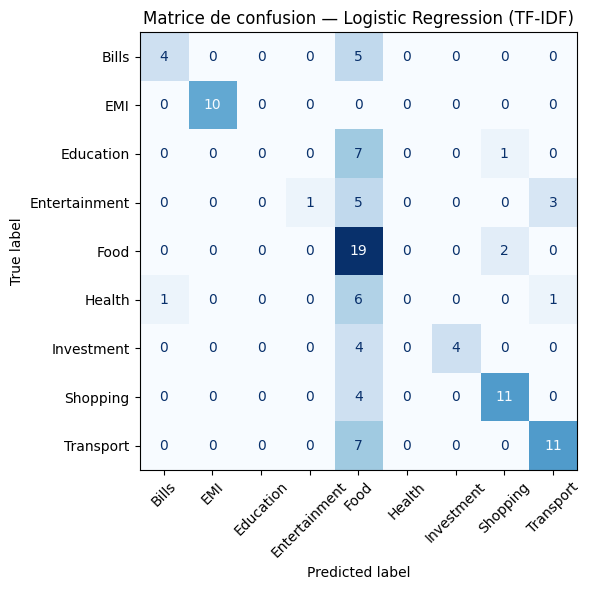

In [7]:
labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred_oof, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"Matrice de confusion — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

## 5. Entraînement final & sauvegarde de l'artefact

Une fois le modèle choisi et validé par cross-validation, on l'entraîne sur **100% des données** disponibles (pas de découpage train/test ici — c'est la validation croisée ci-dessus qui a servi à l'évaluation) et on le sauvegarde au même emplacement que `categorizer.py` l'attend.

In [8]:
final_pipeline = models[BEST_MODEL_NAME]
final_pipeline.fit(X, y)

MODEL_PATH = "../ml/categorizer_model.pkl"
os.makedirs(os.path.dirname(MODEL_PATH) or ".", exist_ok=True)
with open(MODEL_PATH, "wb") as f:
    pickle.dump(final_pipeline, f)

print(f"Modèle sauvegardé : {MODEL_PATH}")

Modèle sauvegardé : ../ml/categorizer_model.pkl


In [9]:
# Vérification rapide sur quelques exemples inédits (jamais vus, formulés différemment)
sanity_checks = [
    "uber eats order",
    "salary deposit",
    "car insurance payment",
    "grocery shopping at carrefour",
    "movie night with friends",
]
for desc in sanity_checks:
    pred = final_pipeline.predict([desc])[0]
    proba = final_pipeline.predict_proba([desc])[0].max()
    print(f"{desc:40s} -> {pred:15s} (confiance {proba*100:.1f}%)")

uber eats order                          -> Transport       (confiance 27.5%)
salary deposit                           -> Food            (confiance 19.3%)
car insurance payment                    -> Food            (confiance 20.8%)
grocery shopping at carrefour            -> Food            (confiance 36.4%)
movie night with friends                 -> Food            (confiance 19.4%)


## 6. Synthèse

- **Dataset** : 106 exemples, 9 catégories, issus de la fusion Kaggle + exemples statiques.
- **Méthode d'évaluation** : StratifiedKFold (5 plis) — nécessaire vu le peu de données par classe.
- **Modèle retenu** : voir `BEST_MODEL_NAME` ci-dessus, à ajuster selon les scores obtenus lors de l'exécution.
- **Limite connue** : dataset encore petit (8-21 exemples/catégorie) — à surveiller si les descriptions réelles saisies par l'utilisateur s'écartent trop du vocabulaire d'entraînement (le test de sanity check ci-dessus donne une idée de la généralisation).